In [1]:
import transformers
import tensorflow as tf
from tensorflow import keras
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt


In [2]:
import zipfile
with   zipfile.ZipFile(r"C:\Users\PC\Downloads\archive (14).zip",'r') as face_mask:
    face_mask_data=face_mask.namelist
    

In [71]:
face_mask_data[]

SyntaxError: invalid syntax (1210877170.py, line 1)

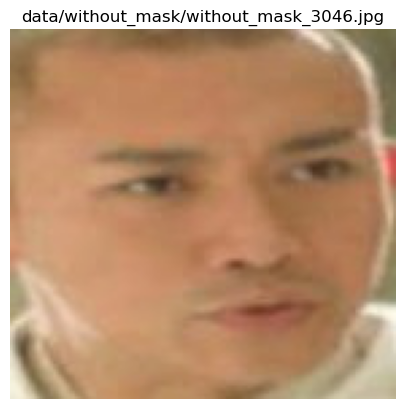

In [3]:

with zipfile.ZipFile(r"C:\Users\PC\Downloads\archive (14).zip") as file:
    face_data=file.namelist()
    face_ims=face_data[6000]

    with file.open(face_ims) as face_or_mask_img:
        img=Image.open(face_or_mask_img)
        plt.imshow(img)
        plt.title(face_ims)
        plt.axis('off')
        plt.show()
        
    #print(len(face_d
        #ata))

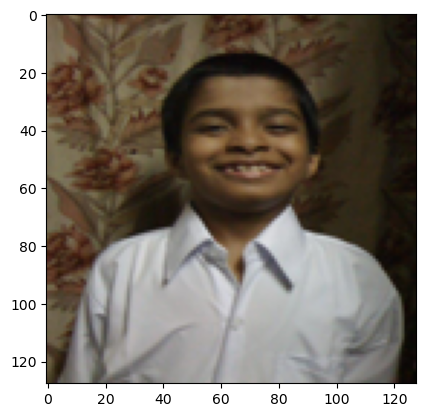

In [13]:
imag_data=[]
with zipfile.ZipFile(r"C:\Users\PC\Downloads\archive (14).zip") as file:
    for f in face_data:
            if 'with_mask' in f.lower() or 'without_mask' in f.lower():
                with file.open(f) as imz_data:
                    imz=Image.open(imz_data).convert('RGB').resize((128,128))
                    plt.imshow(imz)
                    im_arr=np.array(imz)
                    imag_data.append(im_arr)
x=np.array(imag_data)


                    

In [45]:
imag_data
x=np.array(imag_data)

In [41]:
with_mask=0
withput_mask=0
for f in face_data:
    
    if 'with_mask' in f.lower():
        
        with_mask+=1
    elif 'without_mask' in f.lower():
        withput_mask+=1
    

print(f'i have image with mask is: {with_mask}')
print(f'i have image without mask is : {withput_mask}')
        
        
        
    
        

i have image with mask is: 3725
i have image without mask is : 3828


In [42]:
# labels
labels=[]
image_data=[]
for f in face_data:
     if 'with_mask' in f.lower():
         labels.append(0)
     elif 'without_mask' in f.lower():
         labels.append(1)



In [43]:
labels[:20]

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

In [10]:
imag_data[3]

array([[[144, 133, 107],
        [145, 134, 106],
        [143, 130, 103],
        ...,
        [ 31,  28,  32],
        [ 35,  30,  34],
        [ 34,  30,  33]],

       [[147, 136, 109],
        [146, 135, 108],
        [147, 135, 107],
        ...,
        [ 30,  27,  29],
        [ 37,  32,  33],
        [ 34,  29,  30]],

       [[149, 139, 112],
        [146, 135, 108],
        [150, 138, 110],
        ...,
        [ 31,  28,  26],
        [ 37,  30,  28],
        [ 35,  28,  26]],

       ...,

       [[ 38,  79,  78],
        [ 85, 118, 114],
        [121, 141, 134],
        ...,
        [111, 171, 178],
        [139, 186, 191],
        [191, 218, 226]],

       [[ 88, 120, 119],
        [111, 135, 129],
        [124, 137, 127],
        ...,
        [119, 179, 186],
        [123, 173, 176],
        [169, 199, 205]],

       [[112, 133, 136],
        [124, 143, 142],
        [118, 133, 128],
        ...,
        [130, 177, 191],
        [126, 173, 186],
        [146, 186, 201]]

In [46]:

y=np.array(labels)

In [48]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=2)
# scale the data 
x.shape,y.shape

((7553, 128, 128, 3), (7553,))

In [49]:
x=keras.Input(shape=(128,128,3))
h=keras.layers.Conv2D(32,kernel_size=(3,3),activation='relu')(x)
h=keras.layers.MaxPooling2D(pool_size=(2,2))(h)
h=keras.layers.Conv2D(64,kernel_size=(3,3),activation='relu')(h)
h=keras.layers.MaxPooling2D(pool_size=(2,2))(h)
h=keras.layers.Flatten()(h)
h=keras.layers.Dense(128,activation='relu')(h)
h=keras.layers.Dropout(0.5)(h)
h=keras.layers.Dense(64,activation='relu')(h)
h=keras.layers.Dropout(0.5)(h)
out=keras.layers.Dense(1,activation='sigmoid')(h)
model=keras.Model(x,out)
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)           │ (None, 128, 128, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 126, 126, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 61, 61, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 57600)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 128)                 │       7,372,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 7,400,641 (28.23 MB)

 Trainable params: 7,400,641 (28.23 MB)

 Non-trainable params: 0 (0.00 B)

In [91]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])
model.fit(x_train,y_train,epochs=10,batch_size=32,validation_split=0.2)

Epoch 1/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 50s 304ms/step - accuracy: 0.8051 - loss: 0.4265 - val_accuracy: 0.6452 - val_loss: 0.8014
Epoch 2/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 45s 297ms/step - accuracy: 0.7914 - loss: 0.4635 - val_accuracy: 0.6319 - val_loss: 0.8758
Epoch 3/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 45s 294ms/step - accuracy: 0.7877 - loss: 0.4617 - val_accuracy: 0.6873 - val_loss: 0.7550
Epoch 4/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 46s 300ms/step - accuracy: 0.8492 - loss: 0.3536 - val_accuracy: 0.7634 - val_loss: 0.7500
Epoch 5/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 43s 283ms/step - accuracy: 0.8686 - loss: 0.3247 - val_accuracy: 0.7361 - val_loss: 0.7490
Epoch 6/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 50s 326ms/step - accuracy: 0.8885 - loss: 0.2869 - val_accuracy: 0.7618 - val_loss: 0.7024
Epoch 7/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 44s 290ms/step - accuracy: 0.9015 - loss: 0.2779 - val_accuracy: 0.7750 - val_loss: 0.6703
Epoch 8/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 43s 285ms/step - accuracy: 0.9135 - loss: 0

In [95]:
model.evaluate(x_test,y_test)

48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - accuracy: 0.7882 - loss: 0.7377


[0.7376837730407715, 0.7882197499275208]

In [78]:
print("Images:", len(x))
print("Labels:", len(y))

Images: 7553
Labels: 7553


In [83]:
print("With mask:", 3725)
print("Without mask:", 3828)
print("Expected total:", 3725 + 3828)

print("Actual images:", len(x))
print("Actual labels:", len(y))

With mask: 3725
Without mask: 3828
Expected total: 7553
Actual images: 7553
Actual labels: 7553


In [96]:
from keras.models import Sequential

In [97]:
model = keras.Sequential()

model.add(keras.layers.Conv2D(32, kernel_size=(3,3), activation='relu', input_shape=(128,128,3)))
model.add(keras.layers.MaxPooling2D(pool_size=(2,2)))


model.add(keras.layers.Conv2D(64, kernel_size=(3,3), activation='relu'))
model.add(keras.layers.MaxPooling2D(pool_size=(2,2)))

model.add(keras.layers.Flatten())

model.add(keras.layers.Dense(128, activation='relu'))
model.add(keras.layers.Dropout(0.5))

model.add(keras.layers.Dense(64, activation='relu'))
model.add(keras.layers.Dropout(0.5))


C:\Users\PC\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [98]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)                    │ (None, 126, 126, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_8 (MaxPooling2D)       │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_9 (Conv2D)                    │ (None, 61, 61, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_9 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_4 (Flatten)                  │ (None, 57600)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_12 (Dense)                     │ (None, 128)                 │       7,372,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_8 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_13 (Dense)                     │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_9 (Dropout)                  │ (None, 64)                  │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 7,400,576 (28.23 MB)

 Trainable params: 7,400,576 (28.23 MB)

 Non-trainable params: 0 (0.00 B)

In [99]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['acc'])

In [ ]:
model.fit(x_train,y_train,validation_split=0.1,epochs=5)

Epoch 1/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 51s 278ms/step - acc: 0.0116 - loss: 12.8143 - val_acc: 0.0000e+00 - val_loss: 11.1090
Epoch 2/5
 99/170 ━━━━━━━━━━━━━━━━━━━━ 19s 272ms/step - acc: 0.0078 - loss: 14.3854

# TRANSFER LEARING

In [26]:
from tensorflow.keras.applications import MobileNetV2
from keras.models import Sequential
basic_model=MobileNetV2(input_shape=(128,128,3),
                        include_top=False,
                        weights='imagenet'
                       )
basic_model.trainable=False

In [31]:
model=keras.models.Sequential([basic_model,keras.layers.GlobalAveragePooling2D(),
                            keras.layers.Dropout(0.2),
                             keras.layers.Dense(64,activation='relu'),
                               
                             
                             keras.layers.Dense(16,activation='relu'),
                               
                             keras.layers.Dense(1,activation='sigmoid')])


In [57]:
model.compile(optimizer='adam',loss='binary_crossentropy',
             metrics=['accuracy'])

In [58]:
model.fit(x_train,y_train,epochs=10)

Epoch 1/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 45s 224ms/step - accuracy: 0.6056 - loss: 10.8121 
Epoch 2/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 83s 227ms/step - accuracy: 0.6814 - loss: 0.6142
Epoch 3/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 42s 222ms/step - accuracy: 0.6880 - loss: 0.6148
Epoch 4/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 42s 220ms/step - accuracy: 0.7696 - loss: 0.5209
Epoch 5/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 43s 225ms/step - accuracy: 0.7772 - loss: 0.4958
Epoch 6/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 45s 237ms/step - accuracy: 0.8080 - loss: 0.4528
Epoch 7/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 42s 223ms/step - accuracy: 0.8380 - loss: 0.3950
Epoch 8/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 42s 223ms/step - accuracy: 0.8287 - loss: 0.3989
Epoch 9/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 42s 222ms/step - accuracy: 0.8701 - loss: 0.3299
Epoch 10/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 43s 225ms/step - accuracy: 0.8896 - loss: 0.2878


In [59]:
model.evaluate(x_test,y_test)

48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - accuracy: 0.8273 - loss: 0.4111


[0.41107532382011414, 0.8272666931152344]